Install Dependencies

In [1]:
!pip install pysindy scikit-learn scipy matplotlib pandas

In [49]:
from google.colab import files
uploaded = files.upload()

Saving era5_nyc_summer_accum.csv to era5_nyc_summer_accum (2).csv


dTdt range: -2.296761921911422 2.830402021950273

Threshold = 0.01
(x0)' = -0.083 x0 +  0.138 u0 + -0.032 u1

Threshold = 0.03
(x0)' = -0.083 x0 +  0.138 u0 + -0.032 u1

Threshold = 0.05
(x0)' = -0.081 x0 +  0.135 u0


/usr/local/lib/python3.12/dist-packages/pysindy/_core.py:621: UserWarning: Last time point dropped in simulation because interpolation of control input was used. To avoid this, pass in a callable for u.
  warnings.warn(


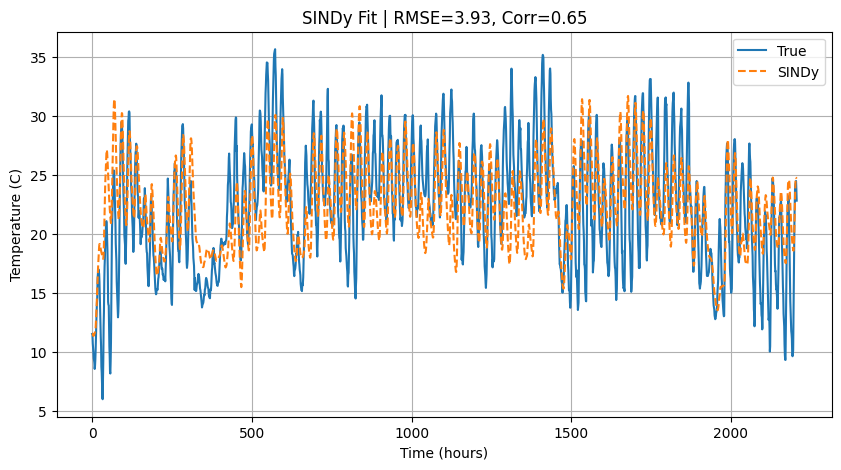

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.preprocessing import StandardScaler
import pysindy as ps

# =========================
# Load data
# =========================
df = pd.read_csv('/content/era5_nyc_summer_accum.csv')
df['valid_time'] = pd.to_datetime(df['valid_time'])

# Select single grid point
lat0 = df['latitude'].iloc[0]
lon0 = df['longitude'].iloc[0]
df = df[(df['latitude'] == lat0) & (df['longitude'] == lon0)]
df = df.sort_values('valid_time')

# =========================
# Variables
# =========================
T = df['temp_C'].values
R = df['ssrd'].values
W = df['wind_speed'].values

dt = 1  # hours

# =========================
# Smooth + derivative
# =========================
T_smooth = savgol_filter(T, window_length=11, polyorder=3)
dTdt = savgol_filter(T, window_length=11, polyorder=3, deriv=1, delta=dt)

print("dTdt range:", dTdt.min(), dTdt.max())

# =========================
# Build dataset
# =========================
X = T_smooth.reshape(-1, 1)
U = np.column_stack([R, W])

# =========================
# Scale
# =========================
scaler_X = StandardScaler()
scaler_U = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
U_scaled = scaler_U.fit_transform(U)

# =========================
# Custom feature library
# =========================
poly_lib = ps.PolynomialLibrary(
    degree=1,
    include_interaction=True,
    include_bias=True
)

# =========================
# Fit SINDy with smaller thresholds
# =========================
thresholds = [0.01, 0.03, 0.05]

models = []

for thresh in thresholds:
    model = ps.SINDy(
        optimizer=ps.STLSQ(threshold=thresh),
        feature_library=poly_lib
    )

    model.fit(X_scaled, u=U_scaled, t=dt)

    print("\n====================")
    print(f"Threshold = {thresh}")
    model.print()

    models.append(model)

# =========================
# Pick best model (usually middle threshold)
# =========================
model = models[1]

# =========================
# Simulate
# =========================
t_sim = np.arange(len(T)) * dt

X_sim = model.simulate(X_scaled[0], t=t_sim, u=U_scaled)
T_sim = scaler_X.inverse_transform(X_sim)

# =========================
# Metrics
# =========================
T_sim_flat = T_sim.flatten()

# Match lengths safely
n = min(len(T), len(T_sim_flat))

T_true_eval = T[:n]
T_pred_eval = T_sim_flat[:n]

rmse = np.sqrt(mean_squared_error(T_true_eval, T_pred_eval))
corr = np.corrcoef(T_true_eval, T_pred_eval)[0, 1]

# =========================
# Plot
# =========================
plt.figure(figsize=(10,5))
plt.plot(T_true_eval, label='True')
plt.plot(T_pred_eval, '--', label='SINDy')

plt.title(f"SINDy Fit | RMSE={rmse:.2f}, Corr={corr:.2f}")
plt.xlabel("Time (hours)")
plt.ylabel("Temperature (C)")
plt.legend()
plt.grid(True)
plt.show()

SINDy Model with Polynomial Degree-2

dTdt range: -2.296761921911422 2.830402021950273

Threshold = 0.01
(x0)' = -0.087 x0 +  0.153 u0 + -0.033 u1 + -0.023 x0 u0

Threshold = 0.02
(x0)' = -0.083 x0 +  0.138 u0 + -0.032 u1

Threshold = 0.05
(x0)' = -0.081 x0 +  0.135 u0

Threshold = 0.1
(x0)' =  0.000


/usr/local/lib/python3.12/dist-packages/pysindy/optimizers/stlsq.py:224: UserWarning: Sparsity parameter is too big (0.1) and eliminated all coefficients
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pysindy/_core.py:621: UserWarning: Last time point dropped in simulation because interpolation of control input was used. To avoid this, pass in a callable for u.
  warnings.warn(


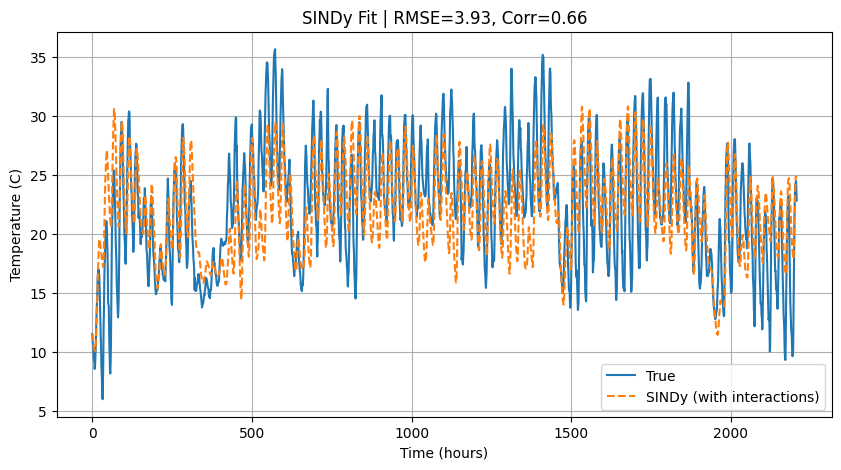

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.preprocessing import StandardScaler
import pysindy as ps
from sklearn.metrics import mean_squared_error

# =========================
# Load data
# =========================
df = pd.read_csv('/content/era5_nyc_summer_accum.csv')
df['valid_time'] = pd.to_datetime(df['valid_time'])

# Select single grid point
lat0 = df['latitude'].iloc[0]
lon0 = df['longitude'].iloc[0]
df = df[(df['latitude'] == lat0) & (df['longitude'] == lon0)]
df = df.sort_values('valid_time')

# =========================
# Variables
# =========================
T = df['temp_C'].values
R = df['ssrd'].values
W = df['wind_speed'].values

dt = 1  # hours

# =========================
# Smooth + derivative
# =========================
T_smooth = savgol_filter(T, window_length=11, polyorder=3)
dTdt = savgol_filter(T, window_length=11, polyorder=3, deriv=1, delta=dt)

print("dTdt range:", dTdt.min(), dTdt.max())

# =========================
# Build dataset
# =========================
X = T_smooth.reshape(-1, 1)
U = np.column_stack([R, W])

# =========================
# Scale
# =========================
scaler_X = StandardScaler()
scaler_U = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
U_scaled = scaler_U.fit_transform(U)

# =========================
# Custom feature library
# =========================
poly_lib = ps.PolynomialLibrary(
    degree=2,
    include_interaction=True,
    include_bias=False
)

# =========================
# Fit SINDy with smaller thresholds
# =========================
thresholds = [0.01, 0.02, 0.05, 0.1]

models = []

for thresh in thresholds:
    model = ps.SINDy(
        optimizer=ps.STLSQ(threshold=thresh),
        feature_library=poly_lib
    )

    model.fit(X_scaled, u=U_scaled, t=dt)

    print("\n====================")
    print(f"Threshold = {thresh}")
    model.print()

    models.append(model)

# =========================
# Pick best model (usually middle threshold)
# =========================
model = models[0]

# =========================
# Simulate
# =========================
t_sim = np.arange(len(T)) * dt

X_sim = model.simulate(X_scaled[0], t=t_sim, u=U_scaled)
T_sim = scaler_X.inverse_transform(X_sim)

# =========================
# Metrics
# =========================
T_sim_flat = T_sim.flatten()

# Match lengths safely
n = min(len(T), len(T_sim_flat))

T_true_eval = T[:n]
T_pred_eval = T_sim_flat[:n]

rmse = np.sqrt(mean_squared_error(T_true_eval, T_pred_eval))
corr = np.corrcoef(T_true_eval, T_pred_eval)[0, 1]

# =========================
# Plot
# =========================
plt.figure(figsize=(10,5))
plt.plot(T_true_eval, label='True')
plt.plot(T_pred_eval, '--', label='SINDy (with interactions)')

plt.title(f"SINDy Fit | RMSE={rmse:.2f}, Corr={corr:.2f}")
plt.xlabel("Time (hours)")
plt.ylabel("Temperature (C)")
plt.legend()
plt.grid(True)
plt.show()